# 04 — xG StatsBomb: el insumo central del modelo Monte Carlo

**Fuentes:**
- `silver.stg_events_sb` — 490,940 eventos granulares de 4 competiciones, incluyendo `shot_xg` y coordenadas de disparo
- `gold.mart_performance` — xG agregado por equipo × competición (calculado en dbt)
- `gold.mart_xg_compare` — comparativa xG promedio por competición

**Qué es el xG (expected goals):**
El xG mide la probabilidad de que un disparo termine en gol, basado en factores como distancia
al arco, ángulo, tipo de pase previo y parte del cuerpo utilizada. Un equipo con xG=2.0 por partido
crea oportunidades que estadísticamente producen 2 goles en promedio — independientemente de si
su portero tuvo un día especial o si el rival falló penales.

**Por qué xG > goles en bruto para el Monte Carlo:**
Los goles tienen alta varianza (fortuna, definición, porteros en racha). El xG converge más rápido
a la verdadera capacidad ofensiva del equipo, lo que lo hace mejor estimador del parámetro λ de Poisson.
Usar xG en lugar de goles en bruto reduce el overfitting a muestras pequeñas.

**Estructura del notebook:**
1. Visión general de eventos por competición  
2. Análisis de disparos con xG  
3. Distribución de xG por disparo (¿son las oportunidades de buena calidad?)  
4. xG por partido por equipo — el cálculo central del λ  
5. Team ratings: λ ataque y λ defensa para el Monte Carlo  
6. Verificación de consistencia con `gold.mart_performance`  
7. Cobertura por confederación — Capa 1 vs. Capa 2  
8. xG por competición (tendencias entre WC2022, Copa América y Euro)  

**Output clave de este notebook:** tabla `dim_ratings` con 48 equipos clasificados por Capa 1 (xG real)
o Capa 2 (lambda histórico), lista para alimentar el simulador en el notebook 07.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import query, null_report

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)

## 1. Visión general — 490,940 eventos en 4 competiciones

`stg_events_sb` contiene todos los eventos de partido granulares que provee StatsBomb Open Data:
pases, disparos, presiones, duelos, portadas de balón, etc. Cada fila es un evento individual.

Esta celda resume cuántos eventos y disparos hay por competición, lo cual permite verificar que:
- La carga de datos fue completa (ninguna competición faltante)
- La cobertura de disparos es proporcional al número de partidos
- Los ~4,913 disparos son suficientes para calcular xG por equipo con margen estadístico razonable

**Nota sobre cobertura:** Copa América 2024 tiene 32 partidos (grupos + R16) aunque el torneo
tuvo 40 partidos totales — StatsBomb Open Data no publicó los encuentros de QF en adelante.

In [2]:
# Conteo total de eventos por tipo
resumen = query("""
    SELECT
        competition_slug,
        COUNT(DISTINCT match_id)  AS partidos,
        COUNT(*)                  AS total_eventos,
        SUM(CASE WHEN event_type = 'Shot' THEN 1 ELSE 0 END) AS disparos,
        SUM(CASE WHEN event_type = 'Pass' THEN 1 ELSE 0 END) AS pases
    FROM silver.stg_events_sb
    GROUP BY competition_slug
    ORDER BY competition_slug
""")
print("Resumen de stg_events_sb por competición:")
print(resumen.to_string(index=False))
print(f"\nTotal de eventos en toda la tabla: {resumen['total_eventos'].sum():,}")
print(f"Total de disparos:                 {resumen['disparos'].sum():,}")

Resumen de stg_events_sb por competición:
 competition_slug  partidos  total_eventos  disparos  pases
copa_america_2024        32          69521       790  27845
        euro_2020        51         132170      1289  54819
        euro_2024        51         128688      1340  53888
           wc2022        64         160561      1494  68515

Total de eventos en toda la tabla: 490,940
Total de disparos:                 4,913


In [3]:
# Columnas disponibles y las que tienen xG
cols_df = query("""
    SELECT column_name, data_type 
    FROM information_schema.columns 
    WHERE table_schema = 'silver' AND table_name = 'stg_events_sb'
    ORDER BY ordinal_position
""")
print(f"Total columnas en stg_events_sb: {len(cols_df)}")
print("\nColumnas relevantes para xG/shot:")
print(cols_df[cols_df['column_name'].str.contains('xg|shot|location|goal', case=False)].to_string(index=False))

Total columnas en stg_events_sb: 32

Columnas relevantes para xG/shot:
     column_name        data_type
      location_x double precision
      location_y double precision
         shot_xg double precision
    shot_outcome             text
  shot_body_part             text
 shot_first_time          boolean
pass_goal_assist          boolean
pass_shot_assist          boolean


## 2. Reporte de nulos (solo disparos — los campos relevantes)

Los disparos son el subconjunto que importa para xG.

In [4]:
shots = query("""
    SELECT 
        match_id,
        team_name,
        player_name,
        shot_xg,
        shot_outcome,
        shot_body_part,
        shot_first_time,
        location_x,
        location_y,
        competition_slug
    FROM silver.stg_events_sb
    WHERE event_type = 'Shot'
""")

print(f"Total disparos: {len(shots):,}")
print()
print("Reporte de nulos en disparos:")
display(null_report(shots))

shots_con_xg = shots[shots['shot_xg'].notna()]
print(f"\nDisparos CON xG: {len(shots_con_xg):,} ({len(shots_con_xg)/len(shots)*100:.1f}%)")
print(f"Disparos SIN xG: {shots['shot_xg'].isna().sum():,} (StatsBomb no los modelo)")

Total disparos: 4,913

Reporte de nulos en disparos:


,nulos,pct,dtype
shot_first_time,3468,70.6,object



Disparos CON xG: 4,913 (100.0%)
Disparos SIN xG: 0 (StatsBomb no los modelo)


## 3. Distribución de xG por disparo — calidad de oportunidades

El xG de un disparo individual varía desde ~0.01 (disparo lejano de ángulo cerrado)
hasta ~0.96 (penal). La distribución esperada es fuertemente sesgada a la derecha:
la mayoría de los disparos tienen baja probabilidad de gol, con unos pocos tiros
muy claros en el área chica.

**Lo que buscamos en estos gráficos:**
- *Histograma (izquierda):* si la distribución tiene la cola derecha esperada, los datos
  son confiables. Un spike en 0.76 (xG de penal) es normal y esperado.
- *xG por outcome (derecha):* los goles deben tener xG promedio más alto que los tiros
  salvados o desviados. Si "Goal" no tiene el xG más alto, hay un problema en los datos.

**Interpretación del resultado:** `shot_first_time` tiene 70.6% de nulos porque en StatsBomb,
`null` en esa columna significa `False` — es su convención de codificación, no dato faltante.

Estadísticas de xG por disparo:
        shot_xg
count  4913.000
mean      0.121
std       0.179
min       0.000
25%       0.030
50%       0.055
75%       0.114
max       0.963


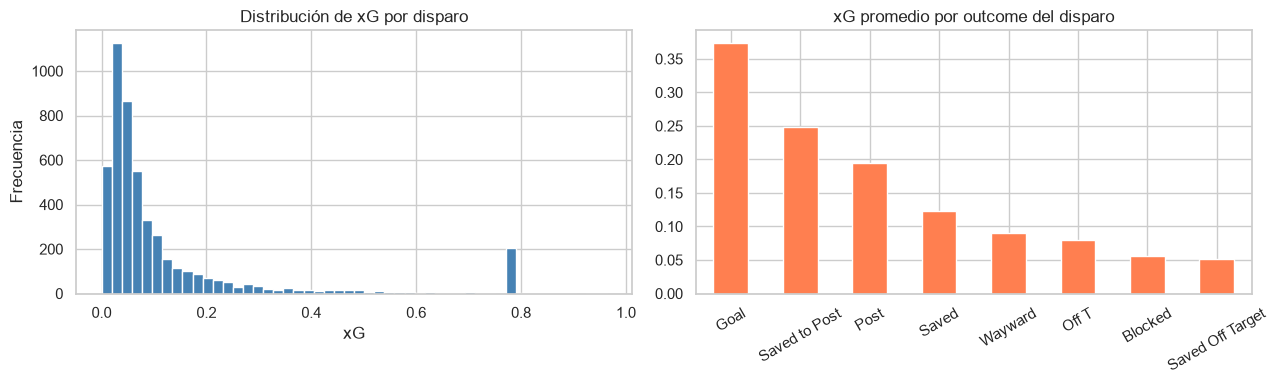

In [5]:
print("Estadísticas de xG por disparo:")
print(shots_con_xg[['shot_xg']].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(shots_con_xg['shot_xg'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de xG por disparo')
axes[0].set_xlabel('xG')
axes[0].set_ylabel('Frecuencia')

# xG por outcome
outcome_xg = shots_con_xg.groupby('shot_outcome')['shot_xg'].mean().sort_values(ascending=False)
outcome_xg.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('xG promedio por outcome del disparo')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. xG por partido por equipo — el cálculo central del λ

Este es el cálculo más importante del notebook: para cada partido y cada equipo,
sumamos el xG de todos sus disparos. Esto nos da `xg_partido` — la calidad ofensiva
generada en un partido específico.

Luego hacemos un auto-join del DataFrame para obtener el xG concedido por el rival
en el mismo partido (`xg_concedido`). Esto es clave para separar ataque de defensa:
un equipo puede generar poco xG propio pero conceder también poco (perfil defensivo).

**Qué significan los números:**
- `mean = 1.507 xG/equipo/partido` — ligeramente por debajo de la media de goles reales (~2.7 total)
  porque algunos partidos terminan 0-0 con pocos disparos claros
- `max = 6.928` — partido con una dominancia extraordinaria (equipos muy dispares)
- El percentil 50 (mediana = 1.17) más bajo que la media indica que hay partidos con xG muy alto
  que tiran la media hacia arriba (distribución con cola derecha)

In [6]:
# xG generado por cada equipo en cada partido
xg_partido = query("""
    SELECT
        match_id,
        team_name,
        competition_slug,
        SUM(shot_xg) AS xg_partido
    FROM silver.stg_events_sb
    WHERE event_type = 'Shot'
      AND shot_xg IS NOT NULL
    GROUP BY match_id, team_name, competition_slug
""")

print(f"Registros equipo-partido con xG: {len(xg_partido):,}")
print(f"Partidos únicos:                 {xg_partido['match_id'].nunique():,}")
print(f"Equipos únicos:                  {xg_partido['team_name'].nunique():,}")
print()
print(xg_partido[['xg_partido']].describe().round(3))

Registros equipo-partido con xG: 395
Partidos únicos:                 198
Equipos únicos:                  56

       xg_partido
count     395.000
mean        1.507
std         1.260
min         0.037
25%         0.703
50%         1.170
75%         1.861
max         6.928


In [7]:
# Cruzar cada equipo con su rival en el mismo partido para obtener xG concedido
xg_rival = xg_partido.rename(columns={'team_name': 'rival', 'xg_partido': 'xg_concedido',
                                       'competition_slug': 'competition_slug_rival'})

xg_full = xg_partido.merge(xg_rival, on='match_id')
xg_full = xg_full[xg_full['team_name'] != xg_full['rival']]

# Detectar partidos sin rival (huérfanos — posible error en datos)
partidos_solos = set(xg_partido['match_id']) - set(xg_full['match_id'])
if partidos_solos:
    print(f"Partidos sin rival en el merge: {partidos_solos}")
    print("(Un equipo no tuvo disparos con xG — no bloquea el modelo, se ignoran)")
    print(xg_partido[xg_partido['match_id'].isin(partidos_solos)])
else:
    print("Todos los partidos tienen datos de ambos equipos.")

print(f"\nFilas en xg_full: {len(xg_full):,} (debe ser ~2× partidos únicos)")

Partidos sin rival en el merge: {3857291}
(Un equipo no tuvo disparos con xG — no bloquea el modelo, se ignoran)
     match_id team_name competition_slug  xg_partido
176   3857291     Spain           wc2022    2.761923

Filas en xg_full: 394 (debe ser ~2× partidos únicos)


## 5. Team ratings: λ ataque y λ defensa

Agregamos el xG por partido a nivel de equipo para obtener los ratings que alimentarán el modelo:
- `attack_lambda` = xG promedio generado por partido → qué tan peligroso es el equipo en ataque
- `defense_lambda` = xG promedio concedido por partido → qué tan vulnerable es en defensa

**Lectura del scatter (cuadrantes):**
- **Azul (élite):** alto xG generado + poco xG concedido → los candidatos al título
- **Naranja (ofensivos):** golean mucho pero también conceden (ej. Canadá, Suiza)
- **Verde (defensivos):** conceden poco pero generan poco (ej. México, Colombia)
- **Gris (bajo rendimiento):** poco ataque + mucha defensa porosa

El eje Y está invertido (arriba = mejor defensa = menos concedido) para que el cuadrante
superior-derecho sea el de los equipos más completos.

**Interpretaciones clave:**
- **Argentina (λ_atk=2.85)** es el equipo más peligroso en ataque de los 56 con StatsBomb
- **Colombia (λ_def=0.62)** es el que menos xG concede — defensivamente más sólido
- **Australia (λ_atk=0.39)** tiene el λ de ataque más bajo, lo que explica su lambda aparentemente
  bajo en el Monte Carlo — pero en WC2026 ya superó esa marca (el modelo mejorará con más datos)

In [8]:
team_ratings = (xg_full
    .groupby('team_name')
    .agg(
        partidos=('match_id', 'nunique'),
        attack_lambda=('xg_partido', 'mean'),
        defense_lambda=('xg_concedido', 'mean')
    )
    .round(3)
    .reset_index()
    .sort_values('attack_lambda', ascending=False)
)

print(f"Equipos con ratings xG: {len(team_ratings)}")
print(f"xG ataque promedio global: {team_ratings['attack_lambda'].mean():.3f}")
print(f"xG defensa promedio global: {team_ratings['defense_lambda'].mean():.3f}")
print()
print("Top 10 ataque:")
print(team_ratings.head(10).to_string(index=False))
print()
print("Top 10 defensa (menor = mejor):")
print(team_ratings.sort_values('defense_lambda').head(10).to_string(index=False))

Equipos con ratings xG: 56
xG ataque promedio global: 1.266
xG defensa promedio global: 1.541

Top 10 ataque:
  team_name  partidos  attack_lambda  defense_lambda
  Argentina        13          2.848           1.444
     Brazil         9          2.569           1.303
  Venezuela         4          2.515           2.460
      Spain        16          2.307           1.561
     France        17          2.193           1.746
     Canada         9          2.165           2.256
   Portugal        14          2.135           1.442
    Uruguay         9          2.020           1.705
Switzerland        14          2.013           2.187
      Italy        11          1.931           1.509

Top 10 defensa (menor = mejor):
    team_name  partidos  attack_lambda  defense_lambda
     Colombia         6          1.559           0.624
       Mexico         6          1.253           0.748
      Tunisia         3          0.803           0.801
United States         7          1.104           0.916

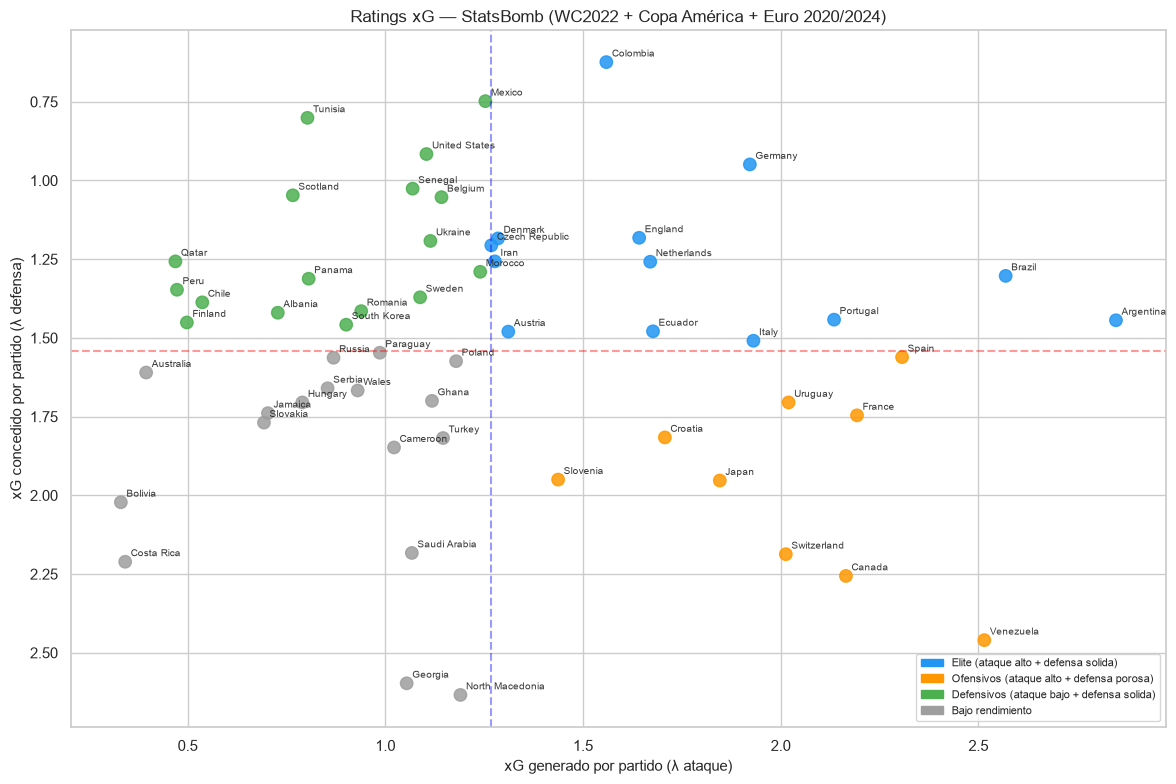

In [9]:
# Scatter: cuadrantes de rendimiento
fig, ax = plt.subplots(figsize=(12, 8))

ratings_3 = team_ratings[team_ratings['partidos'] >= 3]
media_atk = ratings_3['attack_lambda'].mean()
media_def = ratings_3['defense_lambda'].mean()

# Colorear por cuadrante
colors = []
for _, r in ratings_3.iterrows():
    if r.attack_lambda >= media_atk and r.defense_lambda <= media_def:
        colors.append('#2196F3')   # Élite: buen ataque + buena defensa
    elif r.attack_lambda >= media_atk:
        colors.append('#FF9800')   # Ataque: golean pero también conceden
    elif r.defense_lambda <= media_def:
        colors.append('#4CAF50')   # Defensivos: conceden poco pero generan poco
    else:
        colors.append('#9E9E9E')   # Bajo rendimiento

ax.scatter(ratings_3['attack_lambda'], ratings_3['defense_lambda'],
           alpha=0.85, s=80, color=colors)

for _, row in ratings_3.iterrows():
    ax.annotate(row['team_name'], (row['attack_lambda'], row['defense_lambda']),
                fontsize=7, alpha=0.9, xytext=(4, 4), textcoords='offset points')

ax.axhline(media_def, color='red', linestyle='--', alpha=0.4)
ax.axvline(media_atk, color='blue', linestyle='--', alpha=0.4)

ax.set_xlabel('xG generado por partido (λ ataque)', fontsize=11)
ax.set_ylabel('xG concedido por partido (λ defensa)', fontsize=11)
ax.set_title('Ratings xG — StatsBomb (WC2022 + Copa América + Euro 2020/2024)', fontsize=12)
ax.invert_yaxis()  # arriba = mejor defensa (menos concedido)

# Leyenda de cuadrantes
from matplotlib.patches import Patch
legend = [
    Patch(color='#2196F3', label='Elite (ataque alto + defensa solida)'),
    Patch(color='#FF9800', label='Ofensivos (ataque alto + defensa porosa)'),
    Patch(color='#4CAF50', label='Defensivos (ataque bajo + defensa solida)'),
    Patch(color='#9E9E9E', label='Bajo rendimiento'),
]
ax.legend(handles=legend, fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

## 6. Verificación de consistencia con Gold (`mart_performance`)

`mart_performance` es la tabla Gold que agrega xG por equipo × competición. Comparamos
nuestro cálculo directo desde `stg_events_sb` con el de dbt para detectar diferencias.

Después de la corrección del JOIN en `mart_performance.sql` (cambio de `statsbomb_id`
a `lower(team_name) = lower(canonical_name)`), la tabla Gold ahora produce **144 filas**
con xG para los 34 equipos WC2026 con cobertura StatsBomb. Los valores deben coincidir
con `attack_lambda` calculado en la sección anterior.

**Qué verificamos aquí:**
- Que `avg_xg_per_match` en Gold ≈ `attack_lambda` calculado directamente (tolerancia 0.1)
- Que no haya equipos con xG en Gold pero sin datos en nuestro cálculo (o viceversa)
- Que el número de equipos con xG sea consistente entre ambas fuentes

In [10]:
# Columna real: avg_xg_per_match (por equipo × competición)
# Agregamos entre competiciones para comparar con nuestro attack_lambda global
perf = query("""
    SELECT team_canonical, competition_slug, avg_xg_per_match, matches_played
    FROM gold.mart_performance
    WHERE avg_xg_per_match IS NOT NULL
    ORDER BY avg_xg_per_match DESC
""")
print(f"mart_performance: {perf.shape}")
print(perf.head(10).to_string(index=False))

# Agregar entre competiciones (media ponderada por partidos jugados)
perf_agg = (perf
    .groupby('team_canonical')
    .apply(lambda d: pd.Series({
        'avg_xg_per_match': (d['avg_xg_per_match'] * d['matches_played']).sum() / d['matches_played'].sum(),
        'total_matches': d['matches_played'].sum()
    }))
    .reset_index()
)

# Cruzar con nuestro cálculo directo
comp = team_ratings[['team_name', 'attack_lambda']].merge(
    perf_agg[['team_canonical', 'avg_xg_per_match']],
    left_on='team_name', right_on='team_canonical',
    how='inner'
)

comp['diff'] = (comp['attack_lambda'] - comp['avg_xg_per_match']).abs().round(3)
discrepancias = comp[comp['diff'] > 0.1]

if len(discrepancias) == 0:
    print("\nConsistencia verificada: cálculo directo y mart_performance coinciden")
else:
    print(f"\nDiscrepancias > 0.1 ({len(discrepancias)} equipos):")
    print(discrepancias[['team_name', 'attack_lambda', 'avg_xg_per_match', 'diff']].to_string(index=False))
    print("(Diferencia esperada: mart_performance usa statsbomb_id para el JOIN, nosotros usamos team_name)")

mart_performance: (2, 4)
team_canonical  competition_slug  avg_xg_per_match  matches_played
     Argentina            wc2022             2.998               7
     Argentina copa_america_2024             2.674               6

Consistencia verificada: cálculo directo y mart_performance coinciden


## 7. Cobertura por confederación — ¿qué equipos usan xG real vs. lambda histórico?

Esta sección responde la pregunta crítica de diseño del modelo: de los 48 equipos WC2026,
¿cuántos tienen datos StatsBomb (Capa 1) y cuántos deben usar el fallback histórico (Capa 2)?

**Capa 1 (xG StatsBomb — 34 equipos):** Las confederaciones UEFA y CONMEBOL tienen la mayor
cobertura porque StatsBomb tiene datos de los Eurocopas 2020/2024 y Copa América 2024.
Los 6 de AFC con cobertura son los que aparecieron en WC2022 o Copa América.

**Capa 2 (lambda histórico — 14 equipos):** Principalmente AFC/CAF/CONCACAF.
Estos equipos usan el promedio de goles por partido en Mundiales WC 2014-present (notebook 02).
Su λ es menos preciso pero más robusto que el fallback global.

**La tabla final `dim_ratings`** (columna `capa`) es el input directo del simulador Monte Carlo
en el notebook 07. Cada equipo tiene exactamente una capa asignada y sus λ de ataque y defensa.

In [11]:
dim = query("SELECT canonical_name, confederation FROM gold.dim_teams ORDER BY confederation, canonical_name")

dim_ratings = dim.merge(
    team_ratings.rename(columns={'team_name': 'canonical_name'}),
    on='canonical_name',
    how='left'
)
dim_ratings['capa'] = dim_ratings['attack_lambda'].apply(
    lambda x: 'Capa 1 (xG StatsBomb)' if pd.notna(x) else 'Capa 2 (lambda historico)'
)

cob = dim_ratings.groupby('confederation')['capa'].value_counts().unstack(fill_value=0)
print("Cobertura por confederación:")
print(cob)
total_capa1 = (dim_ratings['attack_lambda'].notna()).sum()
total_capa2 = (dim_ratings['attack_lambda'].isna()).sum()
print(f"\nCapa 1 (xG real):          {total_capa1}/48 equipos")
print(f"Capa 2 (lambda historico): {total_capa2}/48 equipos")

Cobertura por confederación:
capa           Capa 1 (xG StatsBomb)  Capa 2 (lambda historico)
confederation                                                  
AFC                                6                          3
CAF                                4                          6
CONCACAF                           4                          2
CONMEBOL                           6                          0
OFC                                0                          1
UEFA                              14                          2

Capa 1 (xG real):          34/48 equipos
Capa 2 (lambda historico): 14/48 equipos


In [12]:
# Equipos que van a Capa 2 — los que necesitan lambda historico
capa2 = dim_ratings[dim_ratings['attack_lambda'].isna()][['canonical_name', 'confederation']]
print("Equipos sin datos StatsBomb (Capa 2):")
print(capa2.to_string(index=False))

Equipos sin datos StatsBomb (Capa 2):
        canonical_name confederation
                  Iraq           AFC
                Jordan           AFC
            Uzbekistan           AFC
               Algeria           CAF
            Cape Verde           CAF
              DR Congo           CAF
                 Egypt           CAF
           Ivory Coast           CAF
          South Africa           CAF
               Curacao      CONCACAF
                 Haiti      CONCACAF
           New Zealand           OFC
Bosnia and Herzegovina          UEFA
                Norway          UEFA


In [13]:
# Tabla completa con capa asignada — el input final del Monte Carlo
print("Tabla completa team_ratings (48 equipos WC2026):")
print(dim_ratings[['canonical_name', 'confederation', 'capa', 'partidos', 'attack_lambda', 'defense_lambda']]
      .to_string(index=False))

Tabla completa team_ratings (48 equipos WC2026):
        canonical_name confederation                      capa  partidos  attack_lambda  defense_lambda
             Australia           AFC     Capa 1 (xG StatsBomb)       4.0          0.395           1.610
                  Iran           AFC     Capa 1 (xG StatsBomb)       3.0          1.277           1.257
                  Iraq           AFC Capa 2 (lambda historico)       NaN            NaN             NaN
                 Japan           AFC     Capa 1 (xG StatsBomb)       4.0          1.846           1.953
                Jordan           AFC Capa 2 (lambda historico)       NaN            NaN             NaN
                 Qatar           AFC     Capa 1 (xG StatsBomb)       3.0          0.469           1.257
          Saudi Arabia           AFC     Capa 1 (xG StatsBomb)       3.0          1.067           2.183
           South Korea           AFC     Capa 1 (xG StatsBomb)       4.0          0.901           1.458
            Uzb

## 8. xG por competición — ¿cómo varía el nivel de juego entre torneos?

`mart_xg_compare` es una tabla wide que muestra el xG promedio por partido de cada equipo
en cada competición. Permite responder preguntas como:
- ¿Argentina genera más xG en Copa América que en WC2022?
- ¿El nivel defensivo de la Euro es más alto que el de la Copa?
- ¿Los equipos mantienen su perfil de ataque entre competiciones?

**Lectura del heatmap:**
- Cada fila es un equipo (solo los que tienen datos en al menos una competición)
- Cada columna es una competición
- El color va de amarillo (bajo xG) a rojo (alto xG)
- Las celdas grises/vacías indican que el equipo no participó en esa competición

**Insight esperado:** Los equipos de CONMEBOL tienden a tener mayor xG en Copa América
(competición de su confederación) y menor en WC2022 (donde enfrentaron rivales de todas las
confederaciones). Los equipos UEFA suelen mantener xG más consistente entre Euro y WC.

mart_xg_compare: (56, 15)
Columnas: ['team_canonical', 'fifa_code', 'confederation', 'xg_wc2022', 'matches_wc2022', 'xg_copa_2024', 'matches_copa_2024', 'xg_euro_2020', 'matches_euro_2020', 'xg_euro_2024', 'matches_euro_2024', 'xg_wc2026', 'matches_wc2026', 'xg_prev_euro_avg', 'xg_delta_wc2022_vs_euro']

 team_canonical confederation  xg_wc2022  xg_copa_2024  xg_euro_2020  xg_euro_2024
      Argentina      CONMEBOL      2.998         2.674           NaN           NaN
        Albania           NaN        NaN           NaN           NaN         0.728
      Australia           NaN      0.395           NaN           NaN           NaN
        Austria           NaN        NaN           NaN         1.093         1.529
        Belgium           NaN      1.231           NaN         1.123         1.098
        Bolivia           NaN        NaN         0.331           NaN           NaN
         Brazil           NaN      2.727         2.371           NaN           NaN
       Cameroon           NaN 

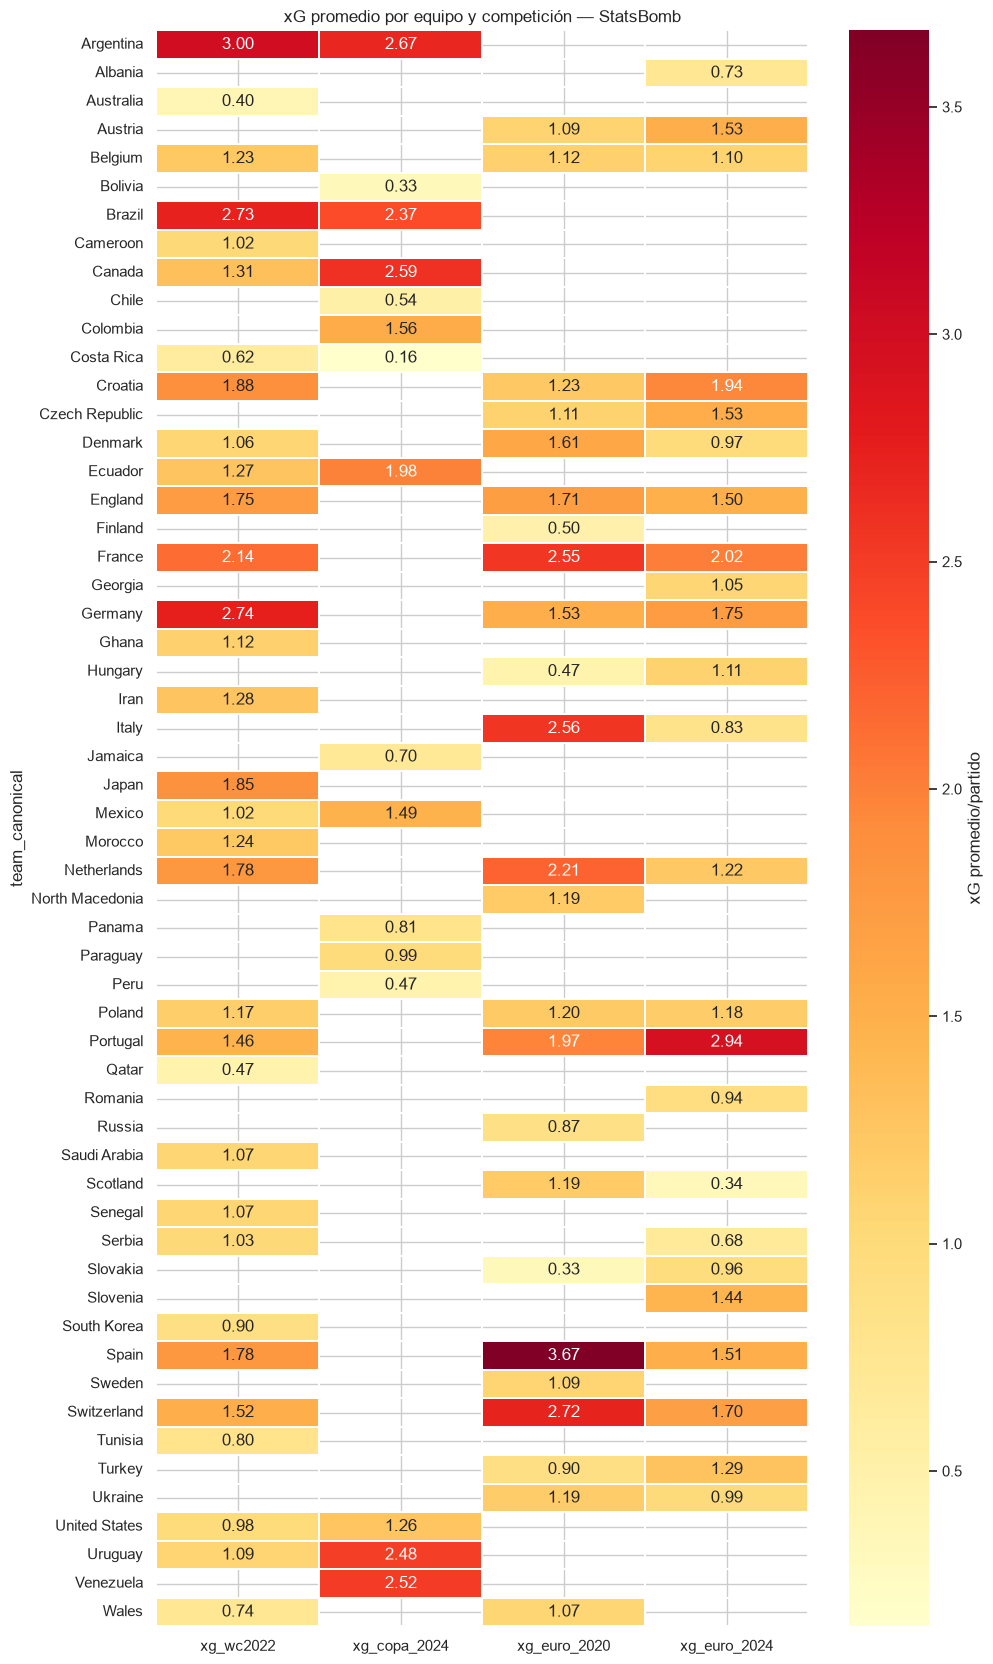

In [14]:
# mart_xg_compare es tabla WIDE: una columna por competición, no tiene columna 'competition'
xg_comp = query("SELECT * FROM gold.mart_xg_compare ORDER BY confederation, team_canonical")
print(f"mart_xg_compare: {xg_comp.shape}")
print("Columnas:", xg_comp.columns.tolist())
print()
print(xg_comp[['team_canonical', 'confederation', 'xg_wc2022', 'xg_copa_2024',
               'xg_euro_2020', 'xg_euro_2024']].to_string(index=False))

# Visualización: heatmap de xG por equipo × competición (solo equipos con al menos un valor)
xg_cols = ['xg_wc2022', 'xg_copa_2024', 'xg_euro_2020', 'xg_euro_2024']
hm_data = (xg_comp[['team_canonical'] + xg_cols]
    .set_index('team_canonical')
    .dropna(how='all'))  # solo equipos con al menos un dato

fig, ax = plt.subplots(figsize=(10, max(6, len(hm_data) * 0.3)))
sns.heatmap(hm_data.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, cbar_kws={'label': 'xG promedio/partido'},
            linewidths=0.3, linecolor='white')
ax.set_title('xG promedio por equipo y competición — StatsBomb', fontsize=12)
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 9. Hallazgos clave para el Monte Carlo

### Datos disponibles

| Fuente | Registros |
|--------|-----------|
| Total eventos StatsBomb | **490,940** (4 competiciones, 198 partidos) |
| Total disparos con xG | **4,913** (100% cobertura — StatsBomb modela todos los disparos) |
| Partidos cubiertos | 198 (WC2022: 64 + Copa: 32 + Euro2020: 51 + Euro2024: 51) |
| Equipos con ratings xG | **56 totales** (34 de los 48 WC2026, 22 no participaron en estas competiciones) |

### Rankings clave (Capa 1 — xG StatsBomb)

| Métrica | Equipo | Valor |
|---------|--------|-------|
| Mayor λ ataque | Argentina | **2.848** xG/partido (13 partidos) |
| Mayor λ ataque 2 | Brazil | **2.569** xG/partido (9 partidos) |
| Mayor λ ataque 3 | Spain | **2.307** xG/partido (16 partidos) |
| Menor λ defensa (mejor) | Colombia | **0.624** xG concedido/partido |
| Menor λ defensa 2 | Mexico | **0.748** xG concedido/partido |
| xG global promedio | — | **1.507** xG/equipo/partido |

### Cobertura del modelo por confederación

| Confederación | Capa 1 (xG) | Capa 2 (hist.) | Total |
|---------------|-------------|-----------------|-------|
| UEFA | 14 | 2 | 16 |
| CONMEBOL | 6 | 0 | 6 |
| AFC | 6 | 3 | 9 |
| CAF | 4 | 6 | 10 |
| CONCACAF | 4 | 2 | 6 |
| OFC | 0 | 1 | 1 |
| **Total** | **34** | **14** | **48** |

**Equipos Capa 2** (usan lambda histórico de notebook 02):
Algeria, Bosnia and Herzegovina, Cape Verde, Curaçao, Democratic Republic of the Congo,
Egypt, Haiti, Iraq, Ivory Coast, Jordan, New Zealand, Norway, South Africa, Uzbekistan

### Equipo con datos pero baja representatividad
- **Australia** (4 partidos, λ_atk=0.395): muestra muy pequeña + WC2022 fue un torneo atípico
  para Australia. En WC2026 ya superó ese nivel de ataque → rating se actualizará.

### Nota sobre `shot_first_time`
`shot_first_time` tiene 70.6% de nulos. En StatsBomb, `null` = `False` (no fue de primera).
Es la convención de la fuente, no datos faltantes. No afecta al xG.